#  Customer Churn Prediction
### Using Random Forest, XGBoost & LightGBM + Rule-Based Logic

---

**Goal:** Predict whether a bank customer is likely to leave (churn) based on their profile and behavior.

**Dataset:** 10,000 bank customers with features like credit score, geography, age, balance, etc.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']

print(" All libraries loaded successfully!")

 All libraries loaded successfully!


## Loading the Dataset

In [18]:
df = pd.read_csv('churn_modelling.csv')

print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (10000, 14)

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [19]:
print(" Dataset Info:")
print(f"  • Rows: {df.shape[0]:,}")
print(f"  • Columns: {df.shape[1]}")
print(f"  • Missing values: {df.isnull().sum().sum()}")
print(f"\n Churn Distribution:")
churn_counts = df['Exited'].value_counts()
print(f"  • Stayed (0): {churn_counts[0]:,} ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"  • Churned (1): {churn_counts[1]:,} ({churn_counts[1]/len(df)*100:.1f}%)")

 Dataset Info:
  • Rows: 10,000
  • Columns: 14
  • Missing values: 0

 Churn Distribution:
  • Stayed (0): 7,963 (79.6%)
  • Churned (1): 2,037 (20.4%)


## Data Cleaning & Preprocessing

In [20]:
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

missing = df_clean.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

dupes = df_clean.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")
if dupes > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"  Dropped {dupes} duplicates. New shape: {df_clean.shape}")

print(f"\n Numerical Feature Summary:")
df_clean.describe().round(2)

No missing values found!

Duplicate rows: 0

 Numerical Feature Summary:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


## Encoding Categorical Features

In [21]:
df_encoded = df_clean.copy()

le = LabelEncoder()
df_encoded['Gender'] = le.fit_transform(df_encoded['Gender'])
print(f"Gender encoded: Female→0, Male→1")

df_encoded = pd.get_dummies(df_encoded, columns=['Geography'], prefix='Geo', drop_first=False)
print(f"Geography one-hot encoded → added columns: {[c for c in df_encoded.columns if 'Geo_' in c]}")

print(f"\n Final shape: {df_encoded.shape}")
print(f"Final columns: {list(df_encoded.columns)}")

Gender encoded: Female→0, Male→1
Geography one-hot encoded → added columns: ['Geo_France', 'Geo_Germany', 'Geo_Spain']

 Final shape: (10000, 13)
Final columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geo_France', 'Geo_Germany', 'Geo_Spain']


## Feature Engineering & Train/Test Split

In [22]:
df_encoded['BalancePerProduct'] = df_encoded['Balance'] / (df_encoded['NumOfProducts'] + 1)
df_encoded['AgeGroup'] = pd.cut(df_encoded['Age'], bins=[0, 30, 45, 60, 100],
                                 labels=[0, 1, 2, 3]).astype(int)
df_encoded['IsHighRisk'] = (
    (df_encoded['Age'] > 45) & 
    (df_encoded['IsActiveMember'] == 0)
).astype(int)

print(" Added 3 engineered features: BalancePerProduct, AgeGroup, IsHighRisk")

X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'BalancePerProduct']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"\n Split Summary:")
print(f"  Train: {X_train.shape[0]:,} rows")
print(f"  Test:  {X_test.shape[0]:,} rows")
print(f"  Features: {X_train.shape[1]}")
print(f"\n  Churn rate in train: {y_train.mean()*100:.1f}%")
print(f"  Churn rate in test:  {y_test.mean()*100:.1f}%")

 Added 3 engineered features: BalancePerProduct, AgeGroup, IsHighRisk

 Split Summary:
  Train: 8,000 rows
  Test:  2,000 rows
  Features: 15

  Churn rate in train: 20.4%
  Churn rate in test:  20.3%


## Model Training

| Model | Description |
|-------|----------|
| **Random Forest** | Lots of independent trees voting together |
| **XGBoost** | Trees that learn from each other's mistakes (gradient boosting) |
| **LightGBM** | Faster gradient boosting with leaf-wise growth |

In [23]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=3,
        eval_metric='logloss',
        random_state=42
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        num_leaves=31,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    f1  = f1_score(y_test, y_pred)
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': acc,
        'auc': auc,
        'f1': f1
    }
    print(f" Accuracy: {acc:.4f} | AUC: {auc:.4f} | F1: {f1:.4f}")

print("\n All models trained!")


Training Random Forest...
 Accuracy: 0.8420 | AUC: 0.8609 | F1: 0.6291

Training XGBoost...
 Accuracy: 0.8385 | AUC: 0.8598 | F1: 0.6325

Training LightGBM...
 Accuracy: 0.8130 | AUC: 0.8578 | F1: 0.6088

 All models trained!


## Model Comparison

In [24]:
summary_df = pd.DataFrame({
    name: {
        'Accuracy': f"{r['accuracy']*100:.2f}%",
        'ROC-AUC':  f"{r['auc']:.4f}",
        'F1 Score': f"{r['f1']:.4f}"
    }
    for name, r in results.items()
}).T

print(" Model Comparison Summary:")
print("="*50)
print(summary_df.to_string())
print("="*50)

 Model Comparison Summary:
              Accuracy ROC-AUC F1 Score
Random Forest   84.20%  0.8609   0.6291
XGBoost         83.85%  0.8598   0.6325
LightGBM        81.30%  0.8578   0.6088


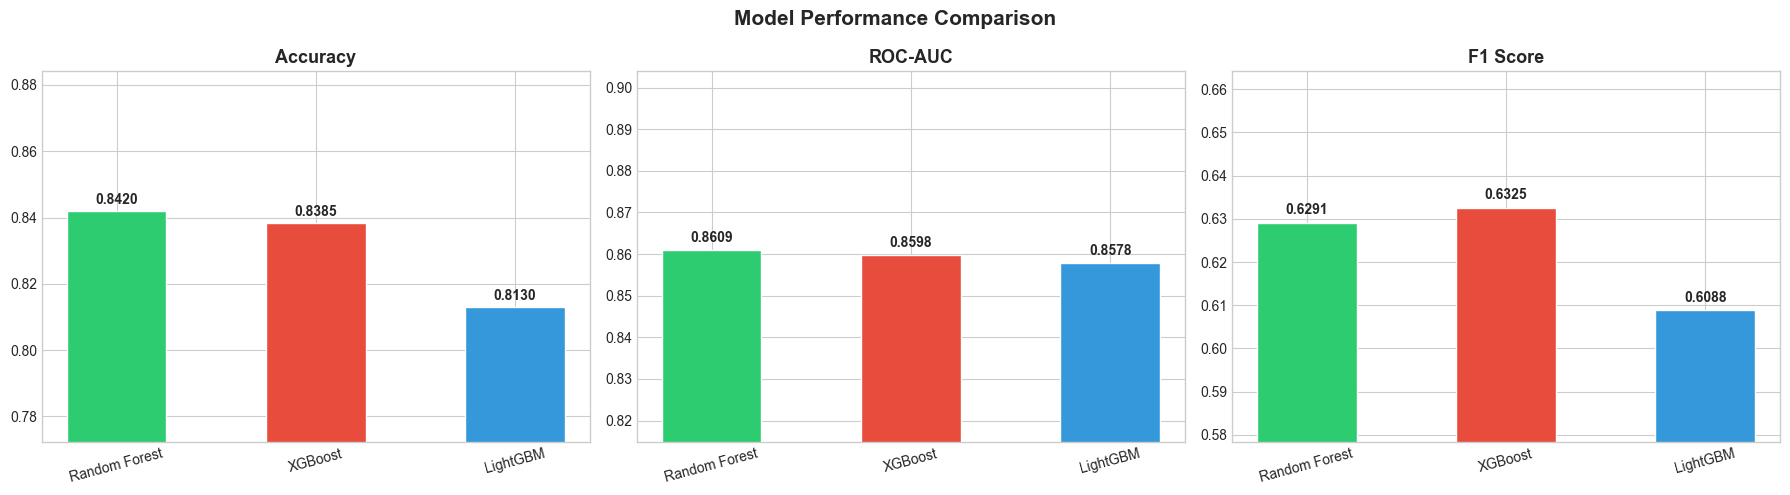

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

names = list(results.keys())
metrics = ['accuracy', 'auc', 'f1']
metric_labels = ['Accuracy', 'ROC-AUC', 'F1 Score']

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[i]
    vals = [results[n][metric] for n in names]
    bars = ax.bar(names, vals, color=COLORS[:3], edgecolor='white', width=0.5)
    ax.set_title(label, fontweight='bold', fontsize=13)
    ax.set_ylim(min(vals)*0.95, min(max(vals)*1.05, 1.0))
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

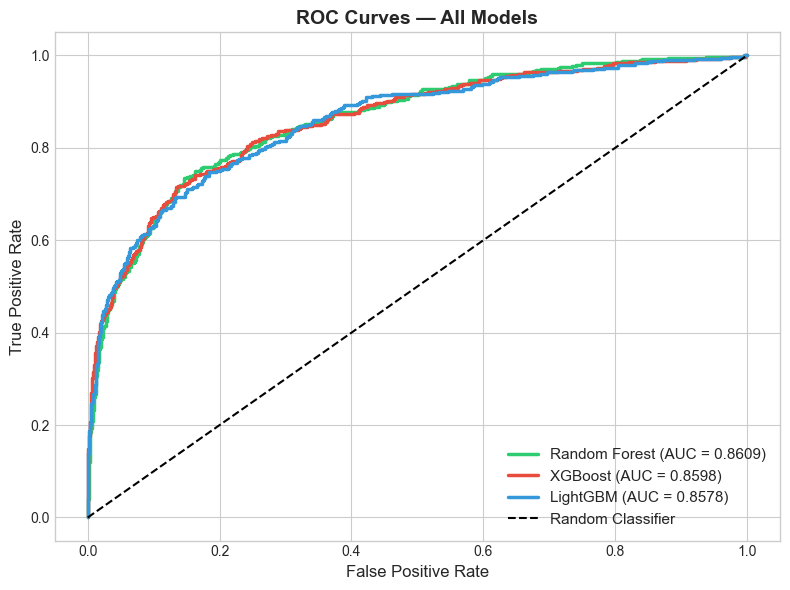

In [26]:
plt.figure(figsize=(8, 6))

for i, (name, r) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    plt.plot(fpr, tpr, color=COLORS[i], linewidth=2.5,
             label=f"{name} (AUC = {r['auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

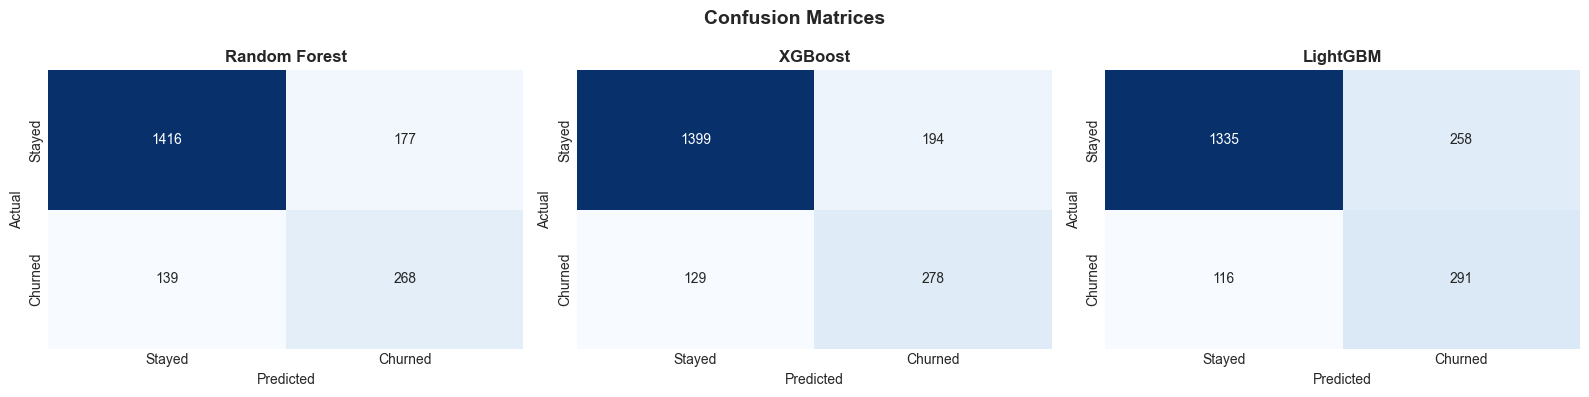

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                cmap='Blues', cbar=False,
                xticklabels=['Stayed', 'Churned'],
                yticklabels=['Stayed', 'Churned'])
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Classification Reports

In [28]:
for name, r in results.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, r['y_pred'], target_names=['Stayed', 'Churned']))


  Random Forest
              precision    recall  f1-score   support

      Stayed       0.91      0.89      0.90      1593
     Churned       0.60      0.66      0.63       407

    accuracy                           0.84      2000
   macro avg       0.76      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000


  XGBoost
              precision    recall  f1-score   support

      Stayed       0.92      0.88      0.90      1593
     Churned       0.59      0.68      0.63       407

    accuracy                           0.84      2000
   macro avg       0.75      0.78      0.76      2000
weighted avg       0.85      0.84      0.84      2000


  LightGBM
              precision    recall  f1-score   support

      Stayed       0.92      0.84      0.88      1593
     Churned       0.53      0.71      0.61       407

    accuracy                           0.81      2000
   macro avg       0.73      0.78      0.74      2000
weighted avg       0.84      0.81 

## Rule-Based Churn Logic

In [29]:
def rule_based_churn(row):
    reasons = []
    risk_score = 0

    geo_germany = row.get('Geo_Germany', 0)
    if geo_germany == 1:
        risk_score += 2
        reasons.append("Based in Germany (higher churn region)")
    
    if row['Age'] > 45 and row['IsActiveMember'] == 0:
        risk_score += 3
        reasons.append("Older customer & inactive member")
    elif row['Age'] > 45:
        risk_score += 1
        reasons.append("Older customer (45+)")
    elif row['IsActiveMember'] == 0:
        risk_score += 1
        reasons.append("Inactive member")
    
    if row['NumOfProducts'] >= 3:
        risk_score += 2
        reasons.append(f"High product count ({int(row['NumOfProducts'])})")
    
    if row['CreditScore'] < 500 and row['IsActiveMember'] == 0:
        risk_score += 2
        reasons.append("Low credit score & inactive")
    elif row['CreditScore'] < 500:
        risk_score += 1
        reasons.append("Low credit score (<500)")

    if row['Tenure'] <= 1:
        risk_score += 1
        reasons.append("Very new customer (tenure ≤1 year)")
    
    prediction = 1 if risk_score >= 3 else 0
    reason_text = "; ".join(reasons) if reasons else "Low risk profile"
    
    return prediction, risk_score, reason_text

test_idx = X_test.index
X_test_orig = df_encoded.loc[test_idx].drop('Exited', axis=1).copy()

rule_preds = []
rule_scores = []

for _, row in X_test_orig.iterrows():
    pred, score, _ = rule_based_churn(row)
    rule_preds.append(pred)
    rule_scores.append(score)

rule_acc = accuracy_score(y_test, rule_preds)
rule_f1  = f1_score(y_test, rule_preds)

print(" Rule-Based System Results:")
print(f"  Accuracy : {rule_acc*100:.2f}%")
print(f"  F1 Score : {rule_f1:.4f}")
print()
print(classification_report(y_test, rule_preds, target_names=['Stayed', 'Churned']))

 Rule-Based System Results:
  Accuracy : 76.65%
  F1 Score : 0.5079

              precision    recall  f1-score   support

      Stayed       0.89      0.81      0.85      1593
     Churned       0.44      0.59      0.51       407

    accuracy                           0.77      2000
   macro avg       0.67      0.70      0.68      2000
weighted avg       0.80      0.77      0.78      2000

